# Semi-discrete convex order and Laguerre tessellation fitting : demo

This notebook describes the implementation and use of the method described in our paper:

*Semi-discrete convex order and Laguerre tessellation fitting* :   https://hal.science/hal-05008630


## 1. Laguerre tessellations

A Laguerre tessellation is a partition of $\mathbb{R}^d$ in $N$ cells defined by :

- **Generators**:  $X= (x_i)_i \in (\mathbb{R}^d)^N, ~  x_i \neq x_j  ~~ \forall\, i\neq j \,, \quad $ 
- **Weights**:  $w= (w_i)_i \in \mathbb{R}^N$

The $i$th cell $L_i(w,X)$ is defined by

$$
		L_i(w,X) = \{ x \in \mathbb{R}^d  \,: \, |x-x_i|^2 -w_i \leq |x-x_j|^2 - w_j \,, ~\forall\, j \neq i\}
$$

In [1]:
# imports

from pysdot.domain_types import ConvexPolyhedraAssembly
from pysdot import PowerDiagram
from pysdot import OptimalTransport


import numpy as np

import matplotlib as mpl
import matplotlib.pyplot as plt

mpl.rcParams.update({
    "font.size": 16,          # base font size
    "axes.titlesize": 18,     # title
    "axes.labelsize": 16,     # x/y labels
    "xtick.labelsize": 14,
    "ytick.labelsize": 14,
    "legend.fontsize": 14,
    "figure.titlesize": 20
})

# vtk
import vtk
from vtk.numpy_interface import dataset_adapter as dsa
from vtk.util.numpy_support import vtk_to_numpy

import ConvexOrderProjectionUtils as cop


In [2]:

# basic power diagram
def make_pd( positions, weights ):
    domain = ConvexPolyhedraAssembly()
    domain.add_box([0, 0], [1, 1])
    
    pd = PowerDiagram(domain)
    pd.set_positions(positions)
    pd.set_weights(weights)
    return pd

In [3]:
# positions and weights
nb_diracs = 100
positions = np.random.rand(nb_diracs, 2)
weights = np.ones(nb_diracs)

# display
import ipywidgets
sl0 = ipywidgets.widgets.FloatSlider(min=1-0.1,max=1+0.1,step=0.001,value=1.0)
sl1 = ipywidgets.widgets.FloatSlider(min=1-0.1,max=1+0.1,step=0.001,value=1.0)
@ipywidgets.interact(w0=sl0, w1=sl1)
def disp(w0, w1):
    weights[ 0 ] = w0
    weights[ 1 ] = w1

    pd = make_pd( positions, weights )
    
    # shift + wheel to zoom in/out
    return pd.display_jupyter( disp_positions=False, disp_ids=False )


<IPython.core.display.Javascript object>

## 2. Motivation: Laguerre Tessellation Fitting

<br>
<div style="display: flex; justify-content: center; align-items: flex-start;">

<div style="text-align: center; margin-right: 50px;">
Electron backscatter diffraction (EBSD) single-phase steel [Tata Steel]<br><br>
<img src="EBSD_image.png" width="200">
</div>

<div style="text-align: center;">
X-ray diffraction Titanium alloy [McDonald et al. 2021]<br><br>
<img src="3dTiAl.png" width="250">
</div>

</div>

<br>

<div style="text-align: center;">
"Far field" 3D X-ray diffraction: <b>only</b> volumes, barycenters and orientations [Petrich et al. '19]
</div>

<br>

<div style="border: 2px solid #d9534f; padding: 10px; border-radius: 5px;">
<b>Laguerre tessellation fitting problem:</b> Given cell volumes $(v_i)_i$ and barycenters $(b_i)_i$:
<br>

$$
\text{Find Laguerre tessellation } (L_i)_i \text{ such that:} \quad |L_i| = v_i \quad \text{and} \quad \mathrm{bary}(L_i) \approx b_i.
$$

</div>

<br>

See [Bourne, Pearce, Roper 2025] for a first method based on <span style="color:red;">semi-discrete Optimal Transport</span> techniques


## 3. Semi-discrete Optimal Transport 

In [4]:
#@title Functions for solving the semi-discrete optimal transport problem

def init_w(x,om):
    """
    This function generates a weight vector w so that the Laguerre tessellation
    of the box om generated by the seeds x and the weights w has cells of
    positive area. It uses the rescaling method from Section 2.2 of the
    following paper:
    J. Meyron. Initialization procedures for discrete and semi-discrete
    optimal transport. Computer-Aided Design, 115:13–22, 2019.

    Inputs:
        x  - seeds, (n,2) numpy array
        om - domain, pysdot ConvexPolyhedraAssembly (assumed to be a rectangle)

    Outputs:
        w - weights of the Laguerre diagram, (n,) numpy array

    """

    # Centroid of the rectangular domain
    com = 0.5 * ( om.max_position() + om.min_position() )

    # Width and height of the rectangular domain
    Lx = om.max_position()[0] - om.min_position()[0]
    Ly = om.max_position()[1] - om.min_position()[1]

    # Define a dilation factor l and a translation t so that the transformed
    # seeds X = l*(x-com) + com = l*x + t lie inside the box. We choose to map
    # the 1st seed to the centre of mass (com) of the box. All the other seeds
    # are dilated about the centre of mass so that they lie inside the box.
    alpha = 0.49
    l = alpha * np.min([Lx,Ly]) / np.max(np.abs(x-x[0,:]))
    t = com - l*x[0,:]

    # The corresponding weight w for the original seeds
    # (see Lemma 2.1 in https://arxiv.org/pdf/2406.00871)
    w = -2.*np.sum(t*x,axis=1) - (l-1.)*np.sum(x*x,axis=1)

    return w

def solve_OT_problem(x,v,om):
    """
    This function uses pysdot to solve the semi-discrete optimal transport
    problem with source measure equal to the Lebesgue measure on the domain om
    and target measure equal to \sum_i v_i \delta_{x_i}.

    Inputs:
        x  - seeds, (n,2) numpy array
        v  - areas, (n,) numpy array
        om - domain, pysdot ConvexPolyhedraAssembly (assumed to be a rectangle)

    Outputs:
        w - weights of the Laguerre diagram, (n,) numpy array
        c - centroids of the Laguerre cells, (n,2) numpy array

    """

    # Error tolerance for the OT solver
    err_tol = 1e-4*np.min(v)

    # Generate initial weights such that all cells have positive area
    w0 = init_w(x,om)

    # Initialise the optimal transport problem
    ot = OptimalTransport(positions = x, masses = v, weights = w0, domain = om,
                          obj_max_dm = err_tol, verbosity = 0,
                          linear_solver = 'Scipy')

    # Solve the optimal transport problem
    ot.adjust_weights()

    # Get cell data
    c = ot.get_centroids() # centroids of the cells
    av = ot.pd.integrals() # areas of the cells
    w = ot.get_weights() # weights

    # Difference between the true areas and target areas
    dv = np.max( np.abs(v-av) )

    # Error message if dv > tolerance
    if dv > err_tol:
        print('Maximum error in volume ',dv)
        raise('Volume tolerance not met')

    return w, c


# Function for plotting the Laguerre tessellation
def plot_cells(x,w,om,ax):

    pd = PowerDiagram(positions=x,weights=w,domain=om)
    tmpvtkfile = "tmp.vtk";
    pd.display_vtk(tmpvtkfile)

    reader = vtk.vtkUnstructuredGridReader()
    reader.SetFileName(tmpvtkfile)
    reader.Update()
    data = reader.GetOutput()

    N = data.GetNumberOfCells()

    numpy_array_of_cells = dsa.WrapDataObject(data).Cells
    numpy_array_of_points = dsa.WrapDataObject(data).Points
    cells = vtk_to_numpy(numpy_array_of_cells)
    verts = vtk_to_numpy(numpy_array_of_points)

    idx = 0
    for k in range(N):
        nv = cells[idx]
        vidx = cells[idx+1:idx+nv+1]
        idx = idx+nv+1
        ax.plot(verts[vidx,0],verts[vidx,1],'k',linewidth=1)
        

In [5]:
Lx = 1.
Ly = 1.
n  = 10

# Generate the rectangular domain
om = ConvexPolyhedraAssembly()
om.add_box([0,0],[Lx,Ly])
Lmat = np.diag([Lx,Ly])

# Positions and masses
X0 = np.random.rand(n,2)@Lmat
v = np.ones(n)/n

# Solve OT problem
w,c = solve_OT_problem(X0,v,om)


pd = make_pd( X0, w )
    
pd.display_jupyter( disp_positions=True, disp_ids=False )

<IPython.core.display.Javascript object>

## 4. Semi-discrete convex order

Fix $\rho \in \mathcal{P}_2(\mathbb{R}^d)$ absolutely continuous and $v_i >0$ such that $\sum_{i=1}^N v_i = 1$.

<br>
<div style="border: 2px solid #d9534f; padding: 10px; border-radius: 5px;">
$$
\mathcal{C}_N(v,\rho) := \{ B = (b_1,\ldots,b_N) \in (\mathbb{R}^d)^N ~:~ \displaystyle \sum_{i=1}^N v_i \delta_{b_i} \preceq_C \rho\}
$$
</div>

$$
B\in \mathcal{C}_N(v,\rho) \iff \sum_i \varphi(b_i)v_i \leq \int_{\mathbb{R}^d} \varphi \,\mathrm{d} \rho \quad \forall\,\varphi:\mathbb{R}^d\rightarrow\mathbb{R} ~ \text{convex}
$$

### 4.1 Properties of $\mathcal{C}_N$

- $\mathcal{C}_N$ is a compact convex subset of $(\mathbb{R}^d)^N$. 
- If $B \in \mathcal{C}_N$ then 
$
\sum_i b_i v_i =\mathrm{bary}(\rho)
$. In particular, we have


$$ \mathrm{dim}(\mathcal{C}_N) = d(N-1)$$

### 4.2 Exposed points

**Weighted inner product**. We define: $~~\langle X,Y\rangle_v : = \sum_i \langle x_i , y_i\rangle v_i$

<br>

<div style="border: 2px solid #5cb85c; padding: 12px; border-radius: 5px; text-align: center">
Maximising $\langle \cdot, X \rangle_v$ over $\mathcal{C}_N(v,\rho)$  $\equiv$ Solving an OT problem from $\rho$ to $ \displaystyle \sum_{i=1}^N v_i \delta_{x_i}$
</div>

<br>


Let $X = (x_1, \ldots, x_N) \in (\mathbb{R}^d)^N$ with $x_i \neq x_j$ for $i \neq j$.


$$
B^* = \mathrm{argmax} \left\{ \langle B, X \rangle_v \;;\; B \in \mathcal{C}_N(v,\rho) \right\}
\iff
b_i^* = \mathrm{bary}_\rho \big( L_i(w^*, X) \big) ~~\forall i \,, \quad \text{where } w^* \text{ satisfies } \quad \rho(L_i(w^*,X)) = v_i ~~ \forall i
$$
<br>

In other words if $B^* = (b_i^*)_i$ satisfies $b_i^* = \mathrm{bary}_\rho \big( L_i(w^*, X) \big) $:
- $B^*$ is an exposed point of $\mathcal{C}_N$ $\leftarrow$ unique minimizer of a linear function on $\mathcal{C}_N$
- $X$ is the direction exposing $B^*$. 
- There exists a unique martingale $\theta \in \Pi\left(\rho, \sum_{i=1}^N \delta_{v_i} b_i^*\right)$, i.e. there exists a unique coupling $\theta \in \Pi\left(\rho, \sum_{i=1}^N \delta_{v_i} b_i^*\right)$,

$$
\int x \, d \theta_{b_i^*}(x)  = b_i^*\,, \quad \text{and this is given by }\quad \theta_{b_i^*} = \frac{1}{v_i} \rho|_{L_i(w^*,X)}
$$

## 5. Reconstruction of Laguerre tessellations from volumes and barycenters

### 5.1 Reconstruction problem and approximation

**Problem** Given $\overline{B}$ with $\overline{b}_i = \mathrm{bary}_\rho(L_i)$ and $(L_i)_i$ a Laguerre tessellation with volumes $\rho(L_i)= v_i$, we seek the unknown generators and weights of the tessellation.

**Approximate solution**

$$
B_\varepsilon = \mathrm{argmin} \left\{ \| (1+\varepsilon) \overline{B}- B \|_v ~;~ B \in \mathcal{C}_N\right\}\,, \quad X_\varepsilon  = (1+\varepsilon) \overline{B}- B
$$

### 5.2 Numerical solution via the Frank-Wolfe algorithm

**Input:** Initial guess $B^0 = \bar{B}$

<br>

<div style="line-height: 2; margin-bottom: 1.5em;">

**For** $n = 0,1,2,\dots$ until convergence:

<ol>
  <li>Compute $X^{n+1} \gets {(1+\varepsilon)\,\bar{B} - B^n}$</li>

  <li>Compute $w$ such that $\rho(L_i(w,X^n)) = v_i$ via damped Newton iterations:
    <ol>
      <li>Compute tessellation: $(L_i(w,X^n))_i$</li>
      <li>Compute: $\mathtt{A}_{ij} = \nabla_{w_j} \rho(L_i), \quad 
      \mathtt{b}_i = v_i - \rho(L_i \cap \Omega)$</li>
      <li>Solve linear system $\mathtt{A} \,\mathtt{x} = \mathtt{b}$ and update weights $w$.</li>
    </ol>
  </li>


  <li>Update $B^{n+1} \gets (\mathrm{bary}_\rho(L_i))_i$</li>
</ol>


In [6]:

def make_data_compatible(vi,bi,om):
    """
    This function modifies the target areas vi and target centroids bi so
    that they belong to the set $\mathcal{D}_n$ defined in Section 3 of this
    paper: https://arxiv.org/pdf/2406.00871

    Inputs:
        vi - initial target areas, (n,) numpy array
        bi - initial target centroids, (n,2) numpy array
        om - domain, pysdot ConvexPolyhedraAssembly (assumed to be a rectangle)

    Outputs:
        vr - target areas, (n,) numpy array
        br - target centroids, (n,2) numpy array

    vi and bi are rescaled so that vr and br satisfy sum(vr)=area(om) and
    and sum(vr*br)=area(om)*com, where com is the centroid of om.

    """

    # First make sure that the target areas sum to the total area of the domain
    total_vol = om.measure() # area of om
    vr = vi*total_vol/vi.sum()

    # Now makes sure that the centroid of the target centroids equals the
    # centroid of the domain
    com = 0.5*(om.max_position()+om.min_position()) # centroid on om
    br = bi + com - np.sum(vr.reshape(-1,1)*bi,axis=0)/total_vol
    return vr, br

def generate_perturbed_voronoi_data(Lx,Ly,n,x_seed=None,p_seed=None,amp=0):
    """
    This function generates synthetic data for the numerical experiments in
    Section 5.1 and 5.2 of the paper https://arxiv.org/pdf/2406.00871
    """

    # Generate the rectangular domain
    om = ConvexPolyhedraAssembly()
    om.add_box([0,0],[Lx,Ly])
    Lmat = np.diag([Lx,Ly])

    # Set the seed for the random number generator
    if x_seed is not None:
        np.random.seed(x_seed)

    # Generate a random collection of seeds
    X0 = np.random.rand(n,2)@Lmat

    # Compute the corresponding Voronoi diagram and the centroids and areas
    # of the Voronoi cells
    pd = PowerDiagram(positions=X0,weights=np.zeros(n),domain=om)
    b = pd.centroids() # centroids of the Voronoi cells
    v = pd.integrals() # areas of the Voronoi cells

    # Perturb the target centroids
    if p_seed is not None:
        np.random.seed(p_seed)
    angles = 2*np.pi*np.random.rand(n,1) # random angles
    unit_vec = np.hstack([np.cos(angles),np.sin(angles)])
    amps = amp*np.random.rand(n,1) # random amplitudes
    perts = unit_vec*amps # random perturbations
    br = b+perts # perturbation of the target centroids

    # Ensure data is compatible
    va, ba = make_data_compatible(v,br,om)
    return va, ba, om, X0

In [7]:

Lx = 1 # width of the rectangular box
Ly = 1 # height of the rectangular box

n = 20 # number of seeds

x_seed = 999 # seed for the random number generator

# Generate a random Voronoi diagram
v, b, om, X0 = generate_perturbed_voronoi_data(Lx, Ly, n, x_seed = x_seed,
                                               p_seed = None, amp = 0)

# Random initial guess for the optimisation method
Lmat=np.diag([Lx,Ly])
xinit=np.random.rand(n,2)@Lmat

In [8]:
#Convex order projection

t = 100 #regularization parameter t>>1
lowerbound = -np.sum(b*b*v.reshape((len(v),1)))/2/(t-1)/t
xt_history, fun_history =cop.convex_order_projection_frank_wolfe(om, t/(t-1)*b, X0, masses = v,  niter= 4000, tol =1e-14)


Iter 558 | f = 3.328141e-05 | FW gap = 1.018093e-14
Success


Text(0.5, 1.0, 'Reconstruction')

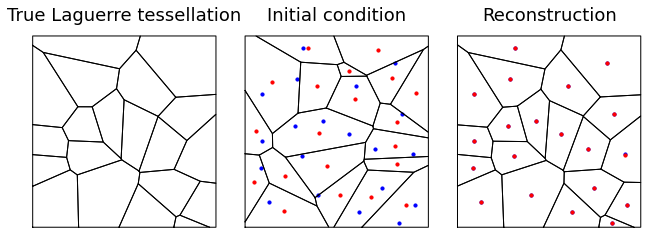

In [9]:
# Plot the results

# Plot the true Laguerre diagram
fig, (ax1,ax2,ax3) = plt.subplots(nrows = 1, ncols = 3, figsize = (9,3.5), layout = 'tight')
plot_cells(X0,np.zeros(n),om,ax1)
ax1.axis('off')
ax1.set_title('True Laguerre tessellation')


# Plot the recovered Laguerre diagram with CO
Z = xinit#t[-1]/(t[-1]-1)*b - np.ones(b.shape)*.5
w, c = solve_OT_problem(Z,v,om)
plot_cells(Z,w,om,ax2)
ax2.axis('off')
ax2.scatter(b[:,0],b[:,1],color='b',s=10) # target centroids in blue
ax2.scatter(c[:,0],c[:,1],color='r',s=10) # centroids of the recovered cells in red
if b.shape == c.shape: diff = np.sqrt(np.sum((b-c)**2))
else: diff = 1000
#ax3.set_title('Convex order. Deviation: {:.3f}'.format(diff) )
ax2.set_title('Initial condition')


# Plot the recovered Laguerre diagram with CO
Z = t/(t-1)*b - xt_history[-1]
w, c = solve_OT_problem(Z,v,om)
plot_cells(Z,w,om,ax3)
ax3.axis('off')
ax3.scatter(b[:,0],b[:,1],color='b',s=10) # target centroids in blue
ax3.scatter(c[:,0],c[:,1],color='r',s=10) # centroids of the recovered cells in red
if b.shape == c.shape: diff = np.sqrt(np.sum((b-c)**2))
else: diff = 1000
#ax3.set_title('Convex order. Deviation: {:.3f}'.format(diff) )
ax3.set_title('Reconstruction')

#plt.savefig('laguerre_fw.png',dpi=300)


Let us check the evolution of the objective $f(B)$ along the iterations: 

$$
f(B) = \| B - (1+\varepsilon) \overline{B}\|
$$

Text(0, 0.5, '$f(B^k) - f(B^*)$')

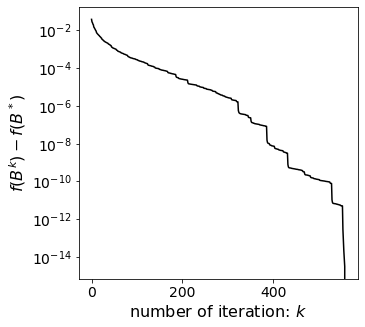

In [10]:
fig,ax = plt.subplots(figsize=(5,5))
ax.semilogy(np.sqrt(fun_history) - np.min(np.sqrt(fun_history)),'k-',linewidth=1.5,label = '$(1)$')
ax.set_xlabel('number of iteration: $k$')
ax.set_ylabel('$f(B^k) - f(B^*)$')



### 5.3 Recovery of aligned seeds


In [11]:
n =40
coords0= np.linspace(0,1,n)
x0, y0 = np.meshgrid(coords0,coords0)
positions = np.zeros((n**2,2))
positions[:,0] = x0.flatten()
positions[:,1] = y0.flatten()
flag_cross = np.logical_or(np.logical_and(positions[:,0]>.33,positions[:,0]<0.67),np.logical_and(positions[:,1]<.67,positions[:,1]>.33))
flag_center = np.logical_or( np.logical_or(positions[:,0]<.33,positions[:,0]>0.67),np.logical_or(positions[:,1]>.67,positions[:,1]<.33))
flag_cross = np.logical_and(flag_cross,flag_center)

#flag_cross = np.logical_and((positions[:,0]-.5)**2 + (positions[:,1]-.5)**2<.35**2,(positions[:,0]-.5)**2 + (positions[:,1]-.5)**2>.21**2)

Y = positions[flag_cross,:].copy()
masses = np.ones(len(Y[:,0]))#np.random.rand(len(Y[:,0]))+.2
masses = masses/np.sum(masses)

w,c = solve_OT_problem(Y,masses,om)
xinit=np.random.rand(len(Y[:,0]),2)@Lmat
t = 100

#Initial condition 1
#w_init,c_init = solve_OT_problem(xinit,masses,om)

#Initial condition 2
xinit = c.copy()
c_init = c.copy()

xt_history, fun_history = cop.convex_order_projection_frank_wolfe(om, t/(t-1)*c, c_init, masses = masses,  niter= 1000,tol =1e-16)



Iter 1001 | f = 3.390565e-05 | FW gap = 6.664038e-09


0.05679265710003191


Text(0.5, 1.0, 'Reconstruction (FW)')

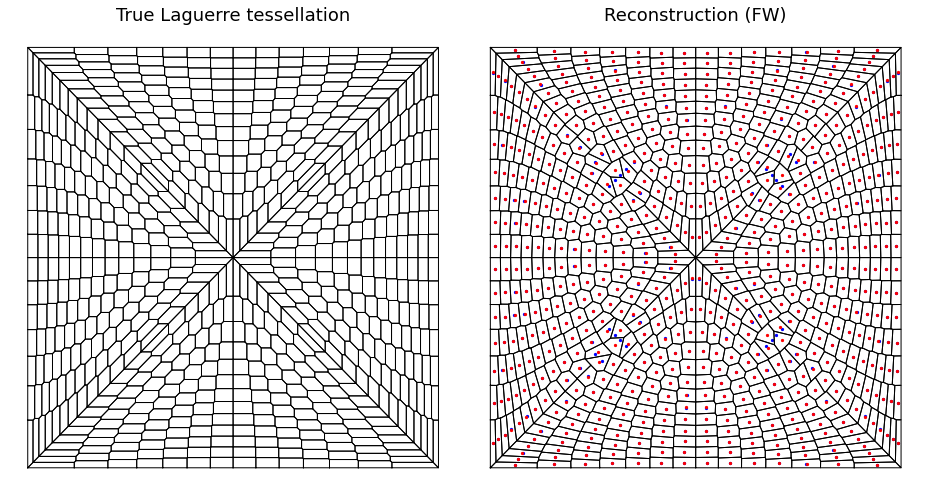

In [12]:

# Plot the true Laguerre diagram
f, (ax1,ax2) = plt.subplots(nrows = 1, ncols =2, figsize = (13,7), layout = 'tight')
w,b = solve_OT_problem(Y,masses,om)
plot_cells(Y, w,om,ax1)
ax1.axis('off')
ax1.set_title('True Laguerre tessellation')


# Plot the recovered Laguerre diagram with CO
Z0 = (t/(t-1)*b - xt_history[-1])
w, c = solve_OT_problem(Z0,masses,om)
plot_cells(Z0,w,om,ax2)
ax2.axis('off')
ax2.scatter(b[:,0],b[:,1],color='b',s=5) # target centroids in blue
ax2.scatter(c[:,0],c[:,1],color='r',s=5) # centroids of the recovered cells in red
if b.shape == c.shape: diff = np.sqrt(np.sum((b-c)**2))
else: diff = 1000
print(diff)
#ax3.set_title('Convex order. Deviation: {:.3f}'.format(diff) )
ax2.set_title('Reconstruction (FW)')



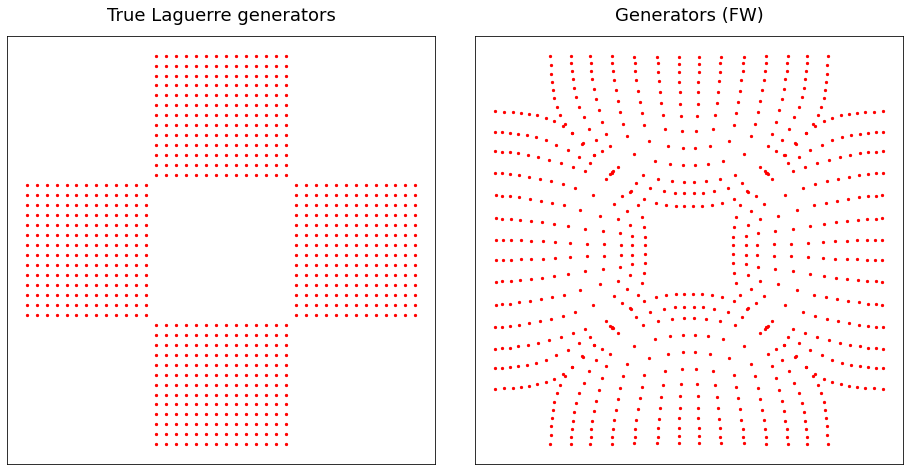

In [13]:

# Plot the true Laguerre diagram
f, (ax1,ax2) = plt.subplots(nrows = 1, ncols = 2, figsize = (13,7))#, layout = 'tight')

#f.subplots_adjust(wspace=.1, hspace=.1)#,left=0.1,top=0.9,right=0.9,bottom=0.1)  # Adjust horizontal and vertical spacing
f.tight_layout(pad=.01) 

#f.subplots_adjust(wspace=1, hspace=1)
ax1.scatter(Y[:,0],Y[:,1],color='r',s=5) # target centroids in blue
ax1.set_title('True Laguerre generators',pad= 15)
ax1.set_xticks([])
ax1.set_yticks([])
ax1.set_aspect('equal', adjustable='box')  # Make the axes square

ax2.scatter(Z0[:,0],Z0[:,1],color='r',s=5) # target centroids in blue
#ax2.axis('off')
#ax3.set_title('Convex order. Deviation: {:.3f}'.format(diff) )
ax2.set_title('Generators (FW)',pad= 15)
ax2.set_xticks([])
ax2.set_yticks([])
ax2.set_aspect('equal', adjustable='box')  # Make the axes square





### 5.4  EBSD data

In [14]:
EBSD = np.loadtxt("EBSD_data.txt")

# Number of grains
n = np.shape(EBSD)[0]
print('Number of grains =',n)

# Areas of the grains
target_areas = EBSD[:,3]

# Centroids of the grains - we will use these as the seeds
target_centroids = EBSD[:,1:3]

# Area and size of the box
total_area = target_areas.sum()
target_centroids = target_centroids/np.sqrt(total_area)
target_areas = target_areas/total_area
total_area = 1.

box_size = np.sqrt(total_area)
print('Box size in microns =',box_size)

# The rectangular domain
OmegaEBSD = ConvexPolyhedraAssembly()
OmegaEBSD.add_box([0,0],[box_size,box_size])

# Ensure that that the target areas sum to the area of the box
target_areas = target_areas*box_size**2/total_area
v, b = make_data_compatible(target_areas,target_centroids,OmegaEBSD)

Number of grains = 243
Box size in microns = 1.0


In [ ]:
# Code to perform the numerical experiment in Section 5.3
# of https://arxiv.org/pdf/2406.00871

# Initial guess for the optimisation method
xinit = b # target centroids

# Tolerances for the optimisation method
ptol = 1e-8
maxiter = 10000 # maximum number of iterations
R0 =1.#250
# Fit a Laguerre diagram to the EBSD data by minimising f

t = 10 #regularization parameter t>>1
xt_history, fun_history = cop.convex_order_projection_frank_wolfe(OmegaEBSD, t/(t-1)*b, .5*np.ones(b.shape), R0=R0, masses = v,  niter= 500, tol =1e-9)

Iter 326 | f = 4.100404e-03 | FW gap = 1.174059e-08


In [ ]:
# Plot the fitted Laguerre diagram overlaid on the EBSD image
f, ax = plt.subplots(figsize=(5,5),layout='tight')
w, c = solve_OT_problem(t/(t-1)*b-xt_history[-1],v,OmegaEBSD)
plot_cells(t/(t-1)*b-xt_history[-1],w,OmegaEBSD,ax)
ax.axis("off")
im = plt.imread('EBSD_image.png')
implot = ax.imshow(im,alpha=0.5,zorder=-1,extent=(0,box_size,0,box_size),origin='lower')
ax.invert_yaxis()
ax.scatter(b[:,0],b[:,1],color='b',s=5) # target centroids in blue
ax.scatter(c[:,0],c[:,1],color='r',s=5) # centroids of the recovered cells in red

plt.savefig('diagram_ebsd.png',dpi=300)

In [ ]:
fig,ax = plt.subplots(figsize=(5,5))
ax.loglog(fun_history - np.min(fun_history),'k-',linewidth=1.5,label = 'FW algorithm')
ax.loglog(np.arange(len(fun_history))[1:],1/(np.arange(len(fun_history))[1:])**2/100,'r--',linewidth=1.5,label = '$k^{-2}$')
ax.legend()
ax.set_xlabel('iteration number $k$')
ax.set_ylabel('$f(B^k) - f(B^*)$')
